#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [ ]:
!pip install -U scikit-learn -q

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
import numpy as np
import matplotlib.pyplot as plt 
import time
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

from statsmodels. tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import (train_test_split, 
                                     GridSearchCV, 
                                     RandomizedSearchCV
                                    )
from sklearn.preprocessing import (LabelEncoder,
                                   MinMaxScaler,
                                   OneHotEncoder,
                                   RobustScaler,
                                   StandardScaler
                                  )
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

try:
    from lightgbm import LGBMRegressor
except:
    !pip install lightgbm -q
    from lightgbm import LGBMRegressor
    
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor

try:
    from catboost import CatBoostRegressor
except:
    !pip install catboost -q
    from catboost import CatBoostRegressor
    
from sklearn.dummy import DummyRegressor

### Чтение данных

In [ ]:
try:
    df = pd.read_csv('/datasets/taxi.csv', parse_dates=[0], index_col=[0])
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv', parse_dates=[0], index_col=[0])
df.sort_index(inplace=True)

print('Первые пять строк: \n', df.head(), '\n-----')
print('Информация о таблице: \n', df.info(), '\n-----')
print('Описание данных: \n', df.describe(), '\n-----')
print('Дубликатов в таблице: \n', df.reset_index().duplicated().sum(), '\n-----')

Первые пять строк: 
                      num_orders
datetime                       
2018-03-01 00:00:00           9
2018-03-01 00:10:00          14
2018-03-01 00:20:00          28
2018-03-01 00:30:00          20
2018-03-01 00:40:00          32 
-----
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
Информация о таблице: 
 None 
-----
Описание данных: 
          num_orders
count  26496.000000
mean      14.070463
std        9.211330
min        0.000000
25%        8.000000
50%       13.000000
75%       19.000000
max      119.000000 
-----
Дубликатов в таблице: 
 0 
-----


### Вывод по подготовке данных
- Данные загружены, столбец datetime приведен к типу datetime64[ns], так же преведен в индекс при загрузке данных. Проведена сортировка по назначенному индексу.

Из информации о данных видно:

- данные разделены на 10 минутные промежутки
- есть периоды с количеством заказов 0 и с максимальным значением 119
- пропуски отсутствуют

## Анализ

###  Ресемплинг по 1 часу

In [4]:
df = df.resample('1H').sum()

print('Первые пять строк: \n', df.head(), '\n-----')
print('Информация о таблице: \n', df.info(), '\n-----')
print('Описание данных: \n', df.describe(), '\n-----')

Первые пять строк: 
                      num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43 
-----
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
Информация о таблице: 
 None 
-----
Описание данных: 
         num_orders
count  4416.000000
mean     84.422781
std      45.023853
min       0.000000
25%      54.000000
50%      78.000000
75%     107.000000
max     462.000000 
-----


- проведен ресемплинрг
- строки уменьшились до 4416
- максимальное количество заказов в час - 462, есть нулевые значения

### График временного ряда, скользящее среднее, скользящее стандартное отклонение

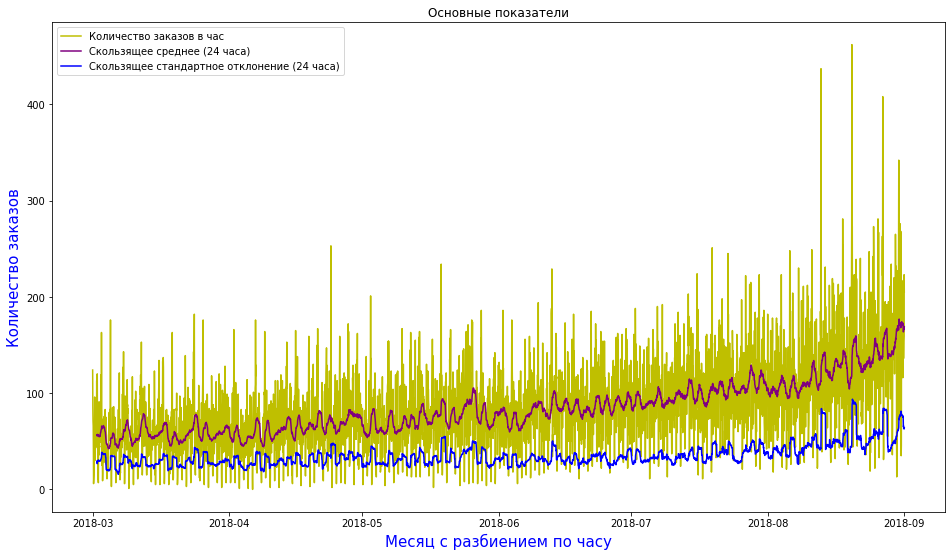

In [5]:
plt.figure(figsize=(16, 9))
plt.plot(df,color='y')
plt.plot(df.shift().rolling(24).mean(),color='purple')
plt.plot(df.shift().rolling(24).std(),color='blue')
plt.title('Основные показатели')
plt.xlabel("Месяц с разбиением по часу", fontsize=15, color='blue')
plt.ylabel("Количество заказов", fontsize=15, color='blue')
plt.legend(['Количество заказов в час', 'Скользящее среднее (24 часа)', 'Скользящее стандартное отклонение (24 часа)'])
plt.show();

### Тест Дики-Фуллера

Гипотезы:

- H0 : Временной ряд нестационарный. То есть он зависит от времени и не имеет постоянной дисперсии во времени.
- H1 : Временной ряд стационарный.

Оценка:
Если p-значение меньше уровня значимости α = 0,05, то мы отвергем нулевую гипотезу и сделаем вывод, что временной ряд является стационарным.

In [6]:
print(f'p-значение = {adfuller(df)[1]:.3f}')

p-значение = 0.029


Так как p-значение меньше 0,05, можно отвергнуть нулевую гипотезу.
Это означает, что временной ряд является стационарным. Он имеет структуру, зависящую от времени, и имеет постоянную дисперсию во времени при оценке уровнем значимости 0,05.

### Тренд, сезонность, остаточный шум.

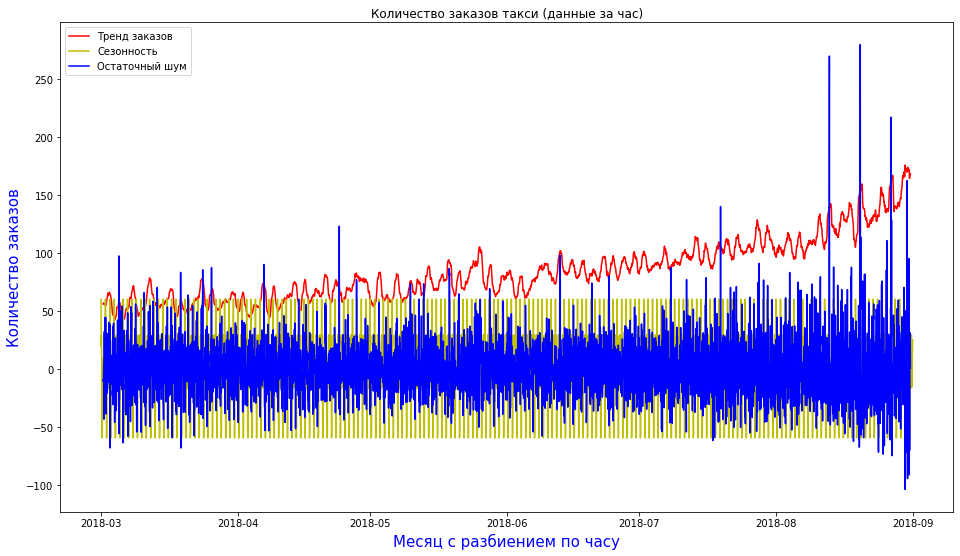

In [7]:
decomposed = seasonal_decompose(df) 
plt.figure(figsize=(16, 9))
plt.plot(decomposed.trend,color='red')
plt.plot(decomposed.seasonal,color='y')
plt.plot(decomposed.resid,color='b')
plt.title('Количество заказов такси (данные за час)')
plt.xlabel("Месяц с разбиением по часу", fontsize=15, color='blue')
plt.ylabel("Количество заказов", fontsize=15, color='blue')
plt.legend(['Тренд заказов', 'Сезонность', 'Остаточный шум'])
plt.show();

### Дневная сезонность

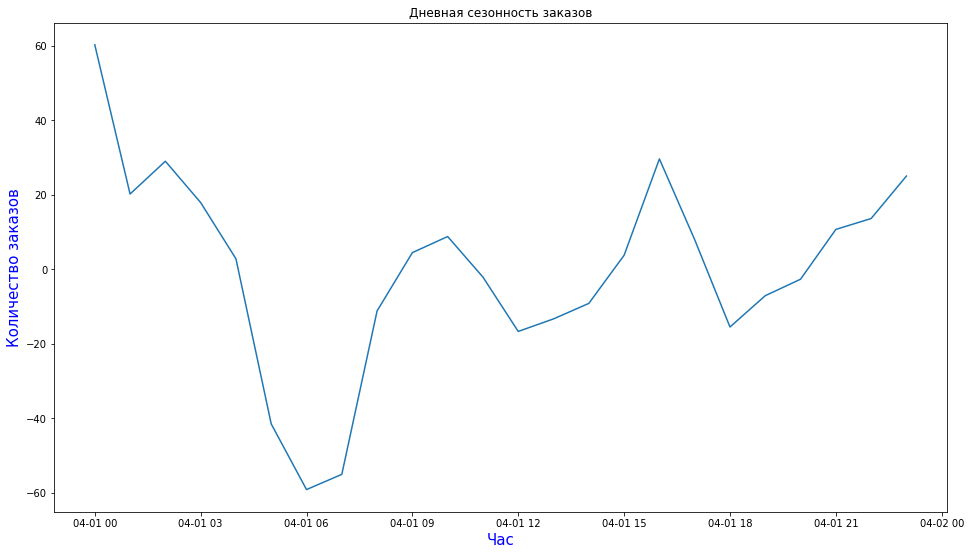

In [8]:
plt.figure(figsize=(16, 9))
fig = plt.plot(decomposed.seasonal['2018-04-01':'2018-04-01'])
plt.title('Дневная сезонность заказов')
ax = plt.gca()
ax.set_xlabel("Час", fontsize=15, color='blue')
ax.set_ylabel("Количество заказов", fontsize=15, color='blue')
plt.show();

### Создание дополнительных признаков

In [9]:
def make_features(data, max_lag, rolling_mean_size):
    data = data.copy()
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    for rol in range(1, rolling_mean_size + 1):
        data['rol_{}'.format(rol)] = data['lag_1'].shift().rolling(rol).mean().round(2)
    return data

In [10]:
max_lag = 24
rolling_mean_size = 7
data = make_features(df, max_lag, rolling_mean_size)
data = data.dropna()
data.head(5)

,num_orders,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rol_1,rol_2,rol_3,rol_4,rol_5,rol_6,rol_7
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,90,2,4,0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,113.0,89.5,80.00,71.25,71.6,67.00,63.57
2018-03-02 01:00:00,120,2,4,1,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,58.0,85.5,79.00,74.50,68.6,69.33,65.71
2018-03-02 02:00:00,75,2,4,2,120.0,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,90.0,74.0,87.00,81.75,77.6,72.17,72.29
2018-03-02 03:00:00,64,2,4,3,75.0,120.0,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,120.0,105.0,89.33,95.25,89.4,84.67,79.00
2018-03-02 04:00:00,20,2,4,4,64.0,75.0,120.0,90.0,58.0,113.0,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,75.0,97.5,95.00,85.75,91.2,87.00,83.29


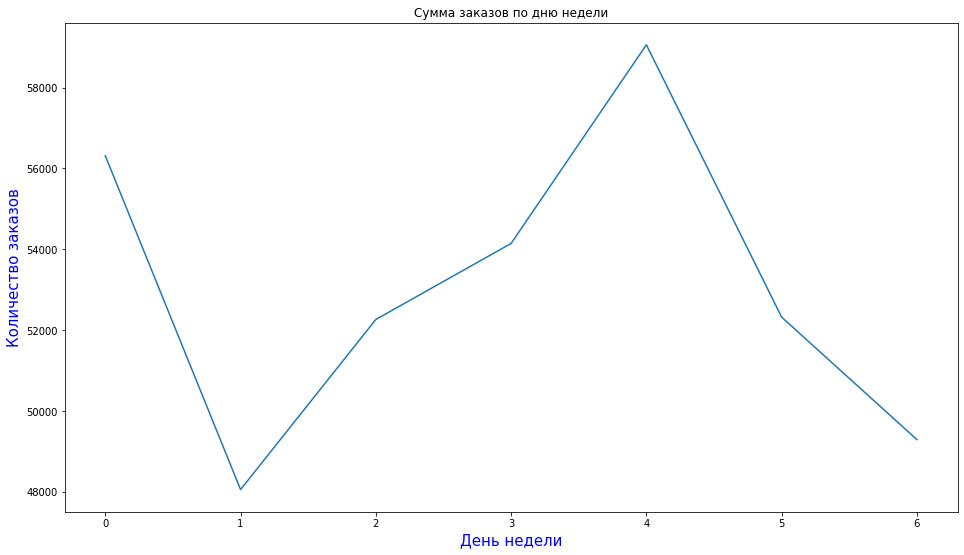

In [11]:
plt.figure(figsize=(16, 9))
fig = plt.plot(data.groupby('dayofweek')['num_orders'].sum())
plt.title('Сумма заказов по дню недели')
ax = plt.gca()
ax.set_xlabel("День недели", fontsize=15, color='blue')
ax.set_ylabel("Количество заказов", fontsize=15, color='blue')
plt.show();

### Вывод по анализу данных¶

- На основании теста Дики-Фуллера c уровнем значимости α = 0,05, делаем вывод, что временной ряд является стационарным. Он имеет структуру, зависящую от времени, и постоянную дисперсию во времени.
- В данных наблюдается возрастающее скользящее среднее до конца представленного периода, это говорит о том, что количество перелетов возрастает, а следовательно и возрастает количество заказов такси.
- Наблюдается сезонность в пределах суток (прослеживаются возрастающие экстремумы заказов: 10 часов, 16 часов, 0 часов), что может свидетельствовать о том что пассажиры предпочитают вылетать и прилетать самолетами утром или вечером, или данные собраны в городе где расписание самолетов преимущественно утреннее или вечернее. Неравномерность графика так же может объясняться расписанием вылета и прилетов самолетов. Минимальное количество вызовов такси в шесть утра.
- Прослеживается рост заказов с минимального количества заказов такси во вторник к пятнице и падением в выходные и понедельник.

## Обучение

### Подготовка данных

In [12]:
X = data.drop(columns=['num_orders'])
y = data['num_orders']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1, shuffle=False)
print(f'Обучающая выбока находится в промежутке от {X_train.index.min()} до {X_train.index.max()}')
print(f'Тестовая выбока находится в промежутке от {X_test.index.min()} до {X_test.index.max()}')
print(f'Разбито в соотношении {round((X_train.shape[0] / X.shape[0]), 2)}:{round((X_test.shape[0] / X.shape[0]), 2)}')

Обучающая выбока находится в промежутке от 2018-03-02 00:00:00 до 2018-08-13 15:00:00
Тестовая выбока находится в промежутке от 2018-08-13 16:00:00 до 2018-08-31 23:00:00
Разбито в соотношении 0.9:0.1


In [13]:
RANDOM_STATE = 42
tscv = TimeSeriesSplit()
print(data.dtypes)

num_orders      int64
day             int64
dayofweek       int64
hour            int64
lag_1         float64
lag_2         float64
lag_3         float64
lag_4         float64
lag_5         float64
lag_6         float64
lag_7         float64
lag_8         float64
lag_9         float64
lag_10        float64
lag_11        float64
lag_12        float64
lag_13        float64
lag_14        float64
lag_15        float64
lag_16        float64
lag_17        float64
lag_18        float64
lag_19        float64
lag_20        float64
lag_21        float64
lag_22        float64
lag_23        float64
lag_24        float64
rol_1         float64
rol_2         float64
rol_3         float64
rol_4         float64
rol_5         float64
rol_6         float64
rol_7         float64
dtype: object


In [14]:
cat_columns = [] 
num_columns = []
for col in X_train.columns: 
    if X_train[col].dtype == 'int': 
        cat_columns.append(col) 
    else: 
        num_columns.append(col)
print(cat_columns) 
print(num_columns)

# пайплайн для подготовки признаков из списка ohe_columns: 
# заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
    )

# общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, cat_columns),
     ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

['day', 'dayofweek', 'hour']
['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'rol_1', 'rol_2', 'rol_3', 'rol_4', 'rol_5', 'rol_6', 'rol_7']


### Модель DecisionTreeRegressor()

In [15]:
pipe_final_dtr = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])
# словарь для модели
param_grid_dtr = [{
                 'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
                 'models__max_depth': ([None]+[i for i in range(2, 7)]),
                 'models__max_features': range(2, 15)                 
}]

grid_dtr = GridSearchCV(estimator=pipe_final_dtr, 
                       param_grid=param_grid_dtr,
                       cv=tscv,
                       scoring='neg_root_mean_squared_error',
                       n_jobs=-1).fit(X_train, y_train)

rmse_dtr_v = abs(grid_dtr.best_score_)
print(f'Значение RMSE на кросс-валидации: {rmse_dtr_v:.3f}')

Значение RMSE на кросс-валидации: 31.076


### Модель LinearRegression()

In [16]:
pipe_final_lr = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])
# словарь для модели
param_grid_lr = [{
                 'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
                 }]

grid_lr = GridSearchCV(estimator=pipe_final_lr, 
                       param_grid=param_grid_lr,
                       cv=tscv,
                       scoring='neg_root_mean_squared_error',
                       n_jobs=-1).fit(X_train, y_train)

rmse_lr_v = abs(grid_lr.best_score_)
print(f'Значение RMSE на кросс-валидации: {rmse_lr_v:.3f}')

Значение RMSE на кросс-валидации: 25.920


### Модель Ridge()

In [17]:
# итоговый пайплайн:
pipe_final_ridge = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', Ridge(random_state=RANDOM_STATE))
])
# словарь для модели
param_grid_ridge = [{
                 'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
                 'models__alpha': (0.001, 0.01, 0.1, 1, 10, 100, 1000),
                 'models__fit_intercept': (True, False), 
                 'models__solver': ('auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga')                    
                                  
}]

grid_ridge = GridSearchCV(estimator=pipe_final_ridge, 
                       param_grid=param_grid_ridge,
                       cv=tscv,
                       scoring='neg_root_mean_squared_error',
                       n_jobs=-1).fit(X_train, y_train)

rmse_ridge_v = abs(grid_ridge.best_score_)
print(f'Значение RMSE на кросс-валидации: {rmse_ridge_v:.3f}')

Значение RMSE на кросс-валидации: 25.717


### Модель Lasso()

In [18]:
pipe_final_lasso = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', Lasso(random_state=RANDOM_STATE))
])
# словарь для модели
param_grid_lasso = [{
                 'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
                 'models__alpha': (0.001, 0.01, 0.1, 1, 10, 100, 1000),
                 'models__fit_intercept': (True, False)                    
                                  
}]

grid_lasso = GridSearchCV(estimator=pipe_final_lasso, 
                       param_grid=param_grid_lasso,
                       cv=tscv,
                       scoring='neg_root_mean_squared_error',
                       n_jobs=-1).fit(X_train, y_train)

rmse_lasso_v = abs(grid_lasso.best_score_)
print(f'Значение RMSE на кросс-валидации: {rmse_lasso_v:.3f}')

Значение RMSE на кросс-валидации: 25.605


### Модель LGBMRegressor()

In [19]:
data[cat_columns] = data[cat_columns].astype('category')

In [20]:
lgb_model = LGBMRegressor(verbose=-1, random_state=RANDOM_STATE)
lgbm_params = {
               'n_estimators': [150, 200],
               'max_depth': ([None]+[i for i in range(2, 7)])
              }

grid_lgbm = GridSearchCV(lgb_model,
                         lgbm_params,
                         cv=tscv,
                         scoring ='neg_mean_squared_error',
                         n_jobs=-1,
                         verbose=0).fit(X_train, y_train)

rmse_lgbm_v = (abs(grid_lgbm.best_score_)**0.5)
print(f'Значение RMSE на кросс-валидации: {rmse_lgbm_v:.3f}')

Значение RMSE на кросс-валидации: 24.907


### Модель CatBoostRegressor()

In [21]:
param_grid_cbr = {'depth': (5, 6, 7),
                 'iterations': range(170, 190, 5), 
                 'learning_rate' : (0.01, 0.05, 0.1)}

grid_cbr = RandomizedSearchCV(estimator=CatBoostRegressor(random_state=RANDOM_STATE, cat_features=cat_columns, verbose=False), 
                             param_distributions=param_grid_cbr,
                             n_iter=50,
                             cv=tscv,
                             scoring='neg_root_mean_squared_error',
                             n_jobs=-1, 
                             random_state=RANDOM_STATE).fit(X_train, y_train)

rmse_cbr_v = abs(grid_cbr.best_score_)
print(f'Значение RMSE на кросс-валидации: {rmse_cbr_v:.3f}')

Значение RMSE на кросс-валидации: 24.219


### Вывод по обучению моделей

Подобраны гиперпараметры для следующих моделей:

- DecisionTreeRegressor
- LinearRegression
- Ridge
- Lasso
- LGBMRegressor 
- CatBoostRegressor

Выберем лучшую модель и протестируем ее.

## Тестирование

### Создание сводной таблицы по обученным моделям

Отберем модель с минимальным значеннием RMSE на валидационной выборке.

In [22]:
results = pd.DataFrame({'Model': ['DecisionTreeRegressor', 'LinearRegression', 'Ridge', 'Lasso', 'LGBMRegressor','CatBoostRegressor'],
                        'RMSE_CV': [rmse_lr_v, rmse_ridge_v, rmse_lasso_v, rmse_dtr_v, rmse_lgbm_v, rmse_cbr_v]})
results = results.sort_values('RMSE_CV').head(1)
results

,Model,RMSE_CV
5,CatBoostRegressor,24.218864


Лучшая модель CatBoostRegressor.

### Расчёт метрики на тестовых данных

In [23]:
print(f'Метрика RMSE на тестовой выборке: {abs(grid_cbr.score(X_test, y_test)):.3f}')

Метрика RMSE на тестовой выборке: 40.945


Полученная метрика RMSE не превышает 48, что соответствует требованиям.

### Проверка лучшей модели моделью DummyRegressor

In [24]:
dummy_regr = DummyRegressor(strategy="mean").fit(X_train, y_train)
print(f'Значение RMSE "DummyRegressor" на тестовой выборке: {(mean_squared_error(y_test, dummy_regr.predict(X_test)))**0.5:.3f}')
print(f'Метрика RMSE на тестовой выборке: {abs(grid_cbr.score(X_test, y_test)):.3f}')
print(f'Значение RMSE выбранной модели на тестовой выборке лучше "DummyRegressor" в {(mean_squared_error(y_test, dummy_regr.predict(X_test)))**0.5 / abs(grid_cbr.score(X_test, y_test)):.3f} раза')

Значение RMSE "DummyRegressor" на тестовой выборке: 84.688
Метрика RMSE на тестовой выборке: 40.945
Значение RMSE выбранной модели на тестовой выборке лучше "DummyRegressor" в 2.068 раза


### Сравнительный анализ реальных и предсказанных данных

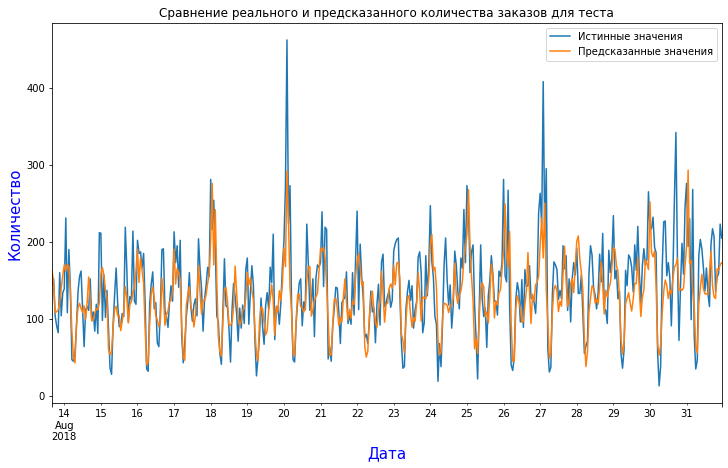

In [25]:
pd.DataFrame({'true': y_test, 'pred': grid_cbr.predict(X_test)}).plot(figsize=(12, 7))
plt.title('Сравнение реального и предсказанного количества заказов для теста')
plt.xlabel('Дата', fontsize=15, color='blue')
plt.ylabel('Количество', fontsize=15, color='blue')
plt.legend(['Истинные значения', 'Предсказанные значения'])
plt.show();

Графики реального и предсказанного количества заказов похожи. На графике реальных данных наблюдаем выбросы 20 и 27 августа (это большое количество заказов).

### График важности признаков

Отобразим 15 наиболее значимых признаков.

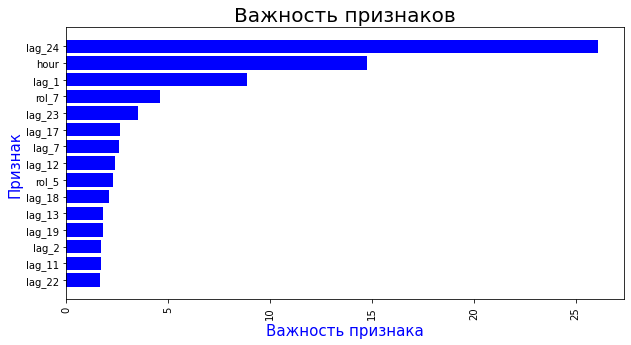

In [26]:
importances = pd.DataFrame(data={'Attribute': X_train.columns,'Importance': grid_cbr.best_estimator_.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=True).tail(15)
plt.figure(figsize=(10, 5))
plt.barh(y=importances['Attribute'], width=importances['Importance'], color='blue')
plt.title('Важность признаков', size=20)
plt.xticks(rotation='vertical')
plt.xlabel('Важность признака', fontsize=15, color='blue')
plt.ylabel('Признак', fontsize=15, color='blue')
plt.show();

Наиболее значимыми признаками являются (по убыванию):

- lag_24 - смещение данных на 24 часа
- hour - дневное время в часах
- lag_1 - смещение данных на 1 час
- lag_7 - смещение данных на 7 часов
- dayofweek - день недели
- lag_17 - смещение данных на 17 часов
- lag_23 - смещение данных на 23 часа
- lag_12 - смещение данных на 12 часов
- lag_7 - смещение данных на 7 часов
- lag_13 - смещение данных на 13 часов
- rol_6 - скользящее среднее с периодом 6 часов
- lag_11 - смещение данных на 11 часов
- lag_18 - смещение данных на 18 часов
- rol_1 - скользящее среднее с периодом 1 час
- lag_9 - смещение данных на 9 часов

Можно уменьшить количество признаков до пяти первых и заново протестировать модели, если метрика RMSE на тестовой выборке будет менее 48, то можно остановиться. При этом обучение моделей будет происходить быстрее.

## Общий вывод

- Проведена сортировка данных по времени и ресемплинг по одному часу.
- Проанализированы графики количества заказов, скользящего стандартного среднего с окном 24 часа, скользящего стандартного отклонения.
- Проанализированы графики количеств заказов, приходящихся на тренд и остатки.
- Проверена стационарность ряда тестом Дики-Фуллера. Ряд имеет некую структуру, зависящую от времени, и  постоянную дисперсию во времени.
- В данных наблюдается возрастающее скользящее среднее до конца представленного периода, что говорит об увеличении количества перелетов, и, следовательно, увеличении количества заказов такси
- Наблюдается сезонность в пределах суток (прослеживаются возрастающие экстремумы заказов: 10 часов, 16 часов, 0 часов), что может свидетельствовать о том что пассажиры предпочитают вылетать и прилетать самолетами утром или вечером, или данные собраны в городе где расписание самолетов преимущественно утреннее или вечернее. Неравномерность графика так же может объясняться расписанием вылета и прилетов самолетов. Минимальное количество вызовов такси в шесть утра.
- Прослеживается рост заказов с минимального количества заказов такси во вторник к пятнице и падением в выходные и понедельник
- Сформированы категориальные признаки (час, день, день недели) и числовые признаки (смещение количества заказов) и скользящие средние.
- Данные поделены на обучающую и тестовую выбоку в соотношении 90 на 10
- Из обучающих данных удалены пропущенные значения, появившиеся в процессе формирования столбцов.
- В процессе обучения были подобраны гиперпараметры для следующих моделей:
   - DecisionTreeRegressor
   - LinearRegression
   - Ridge
   - Lasso
   - LGBMRegressor
   - CatBoostRegressor
- Лучшей моделью является CatBoostRegressor, выбор по минимальному значению RMSE на валидационной выборке.
- Полученная метрика на тестовых данных RMSE не превышает заданного порога 48.
- Построены графики реального количества заказов и предсказанного моделью для тестовой выборки. Графики похожи, но есть два выброса, которые модель не смогла точно предсказать.
- Представлен график важности признаков для модели CatBoostRegressor. Наиболее значимыми признаками являются (по убыванию):
   - lag_24 - смещение данных на 24 часа
   - hour - дневное время в часах
   - lag_1 - смещение данных на 1 час
   - lag_7 - смещение данных на 7 часов
   - dayofweek - день недели